## Kết nối database

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

In [2]:
from utils.config import DB_CONFIG
from utils.db import *

In [3]:
print(DB_CONFIG)

{'host': 'localhost', 'port': 3306, 'user': 'root', 'password': 'da05', 'database': 'sakila'}


In [4]:
engine = make_engine(DB_CONFIG)
test_connection(engine)

Connected — MySQL 8.0.46


In [6]:
query2 = """ 
-- 1. CTE Gom nhóm thông tin Phim & Diễn viên (Chỉ trả về đúng 1 dòng / 1 phim)
WITH film_actors_cte AS (
    SELECT 
        f.film_id,
        f.title,
        f.rating,
        c.name AS category_name,
        GROUP_CONCAT(DISTINCT CONCAT(a.first_name, ' ', a.last_name) SEPARATOR ', ') AS actors_list
    FROM film f
    JOIN film_category fc ON f.film_id = fc.film_id
    JOIN category c ON c.category_id = fc.category_id
    JOIN film_actor fa ON fa.film_id = f.film_id
    JOIN actor a ON a.actor_id = fa.actor_id
    GROUP BY f.film_id, f.title, f.rating, c.name
),

-- 2. CTE Gom nhóm Doanh thu theo Phim (Chỉ trả về đúng 1 dòng / 1 phim)
film_revenue_cte AS (
    SELECT 
        i.film_id,
        COUNT(DISTINCT r.rental_id) AS total_rentals,
        SUM(p.amount) AS total_revenue
    FROM inventory i
    JOIN rental r ON r.inventory_id = i.inventory_id
    JOIN payment p ON p.rental_id = r.rental_id
    GROUP BY i.film_id
)

-- 3. JOIN 2 CTE đã gom gọn lại với nhau (Kết quả cực kỳ gọn nhẹ)
SELECT 
    fa.title,
    fa.rating,
    fa.category_name,
    fa.actors_list,
    COALESCE(fr.total_rentals, 0) AS total_rentals,
    COALESCE(fr.total_revenue, 0) AS total_revenue
FROM film_actors_cte fa
LEFT JOIN film_revenue_cte fr ON fa.film_id = fr.film_id
        """  
# df = load_main_dataset(query, engine)
df2 = pd.read_sql(query2, con = engine)
df2.head()

,title,rating,category_name,actors_list,total_rentals,total_revenue
0,ACADEMY DINOSAUR,PG,Documentary,"CHRISTIAN GABLE, JOHNNY CAGE, LUCILLE TRACY, M...",23,36.77
1,ACE GOLDFINGER,G,Horror,"BOB FAWCETT, CHRIS DEPP, MINNIE ZELLWEGER, SEA...",7,52.93
2,ADAPTATION HOLES,NC-17,Documentary,"BOB FAWCETT, CAMERON STREEP, JULIANNE DENCH, N...",12,37.88
3,AFFAIR PREJUDICE,G,Horror,"FAY WINSLET, JODIE DEGENERES, KENNETH PESCI, O...",23,91.77
4,AFRICAN EGG,G,Family,"DUSTIN TAUTOU, GARY PHOENIX, MATTHEW CARREY, M...",12,51.88


In [8]:
query = """ 
        select t2.orderNumber,
		t2.orderDate,
        t2.shippedDate,
        t2.status as orderStatus,
        t3.customerNumber,
        t3.customerName,
        t3.country as customerCountry,
        t3.city as customerCity,
        t3.creditLimit,
        concat(t4.firstName, ' ', t4.lastName) as salesRep,
        t5.productName,
        t5.productLine,
        t5.quantityInStock,
        t1.quantityOrdered,
        t1.priceEach,
        t1.quantityOrdered * t1.priceEach as lineRevenue
from classicmodels.orderdetails t1
join classicmodels.orders t2 on t1.orderNumber = t2.orderNumber
join classicmodels.customers t3 on t2.customerNumber = t3.customerNumber
join classicmodels.employees t4 on t3.salesRepEmployeeNumber = t4.employeeNumber
join classicmodels.products t5 on t1.productCode = t5.productCode
        """  
# df = load_main_dataset(query, engine)
df = pd.read_sql(query, con = engine)
df.head()

,orderNumber,orderDate,shippedDate,orderStatus,customerNumber,customerName,customerCountry,customerCity,creditLimit,salesRep,productName,productLine,quantityInStock,quantityOrdered,priceEach,lineRevenue
0,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,1917 Grand Touring Sedan,Vintage Cars,2724,30,136.00,4080.00
1,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,1911 Ford Town Car,Vintage Cars,540,50,55.09,2754.50
2,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,1932 Alfa Romeo 8C2300 Spider Sport,Vintage Cars,6553,22,75.46,1660.12
3,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,1936 Mercedes Benz 500k Roadster,Vintage Cars,2081,49,35.29,1729.21
4,10101,2003-01-09,2003-01-11,Shipped,128,"Blauer See Auto, Co.",Germany,Frankfurt,59700.0,Barry Jones,1932 Model A Ford J-Coupe,Vintage Cars,9354,25,108.06,2701.50


In [5]:
df.shape

(2996, 16)

In [6]:
df['orderDate'] = pd.to_datetime(df['orderDate'])
df['shippedDate'] = pd.to_datetime(df['shippedDate'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2996 entries, 0 to 2995
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   orderNumber      2996 non-null   int64        
 1   orderDate        2996 non-null   datetime64[s]
 2   shippedDate      2855 non-null   datetime64[s]
 3   orderStatus      2996 non-null   str          
 4   customerNumber   2996 non-null   int64        
 5   customerName     2996 non-null   str          
 6   customerCountry  2996 non-null   str          
 7   customerCity     2996 non-null   str          
 8   creditLimit      2996 non-null   float64      
 9   salesRep         2996 non-null   str          
 10  productName      2996 non-null   str          
 11  productLine      2996 non-null   str          
 12  quantityInStock  2996 non-null   int64        
 13  quantityOrdered  2996 non-null   int64        
 14  priceEach        2996 non-null   float64      
 15  lineRevenue    

In [7]:
from utils.cleaning import *

In [8]:
# Truoc khi ep kieu du lieu
mb_before = df.memory_usage(deep=True).sum()/1024**2
print(f"Before is {mb_before:.2f} MB")

# Thuc hien ep kieu du lieu
df = optimize_dtypes(df)

# Sau khi ep kieu du lieu
mb_after = df.memory_usage(deep=True).sum()/1024**2
print(f"Before is {mb_after:.2f} MB")


Before is 0.62 MB
Before is 0.51 MB


In [9]:
# Flagging null date column

df["isShipped"] = df["shippedDate"].notna().astype("int")
# df["shippedDate"].notna().astype("int")
df.head()

,orderNumber,orderDate,shippedDate,orderStatus,customerNumber,customerName,customerCountry,customerCity,creditLimit,salesRep,productName,productLine,quantityInStock,quantityOrdered,priceEach,lineRevenue,isShipped
0,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,1917 Grand Touring Sedan,Vintage Cars,2724,30,136.000000,4080.000000,1
1,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,1911 Ford Town Car,Vintage Cars,540,50,55.090000,2754.500000,1
2,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,1932 Alfa Romeo 8C2300 Spider Sport,Vintage Cars,6553,22,75.459999,1660.119995,1
3,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,1936 Mercedes Benz 500k Roadster,Vintage Cars,2081,49,35.290001,1729.209961,1
4,10101,2003-01-09,2003-01-11,Shipped,128,"Blauer See Auto, Co.",Germany,Frankfurt,59700.0,Barry Jones,1932 Model A Ford J-Coupe,Vintage Cars,9354,25,108.059998,2701.500000,1


In [10]:
from utils.stats import *

In [11]:
describe_all(df)

=== Numeric ===
       orderNumber  customerNumber  creditLimit  quantityInStock  quantityOrdered  priceEach  lineRevenue  isShipped
count      2996.00         2996.00      2996.00          2996.00          2996.00    2996.00      2996.00    2996.00
mean      10260.35          259.68    109463.08          5050.08            35.22      90.77      3205.67       0.95
std          92.48          118.41     51542.10          2925.00             9.83      36.58      1632.01       0.21
min       10100.00          103.00     11000.00            15.00             6.00      26.55       481.50       0.00
25%       10181.00          145.00     77700.00          2378.00            27.00      62.00      1990.28       1.00
50%       10262.00          240.00     95000.00          5437.50            35.00      85.81      2880.24       1.00
75%       10338.25          353.00    119600.00          7689.00            43.00     114.65      4093.92       1.00
max       10425.00          496.00    227600.00 

In [34]:
from utils.visual import *

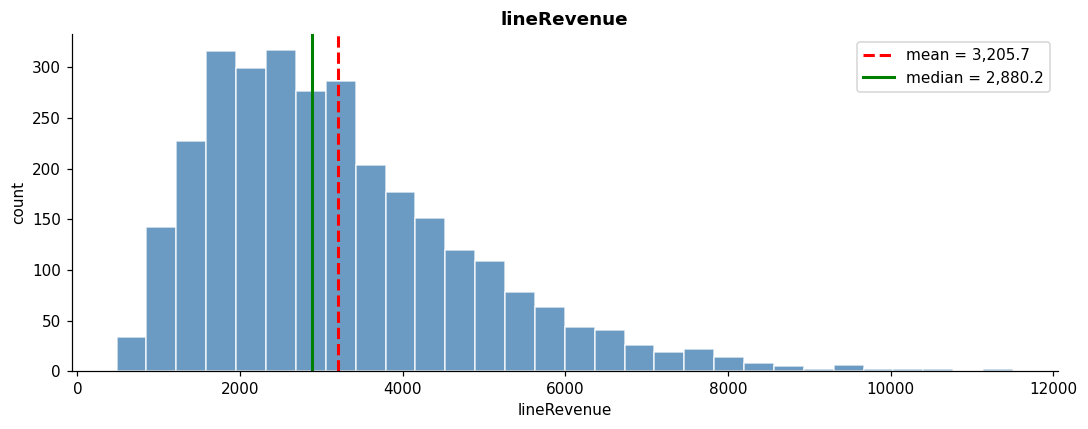

In [14]:
# lineRevenue
plot_histogram(df, "lineRevenue")

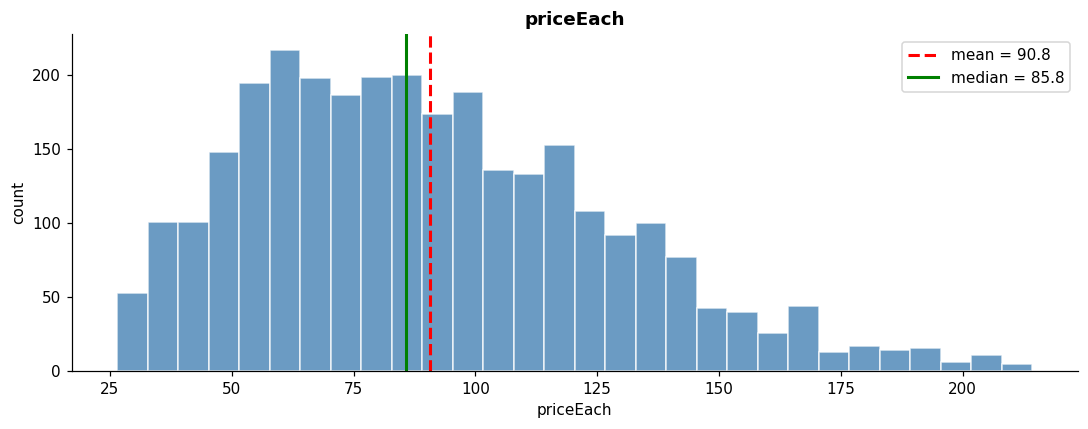

In [15]:
plot_histogram(df, "priceEach")

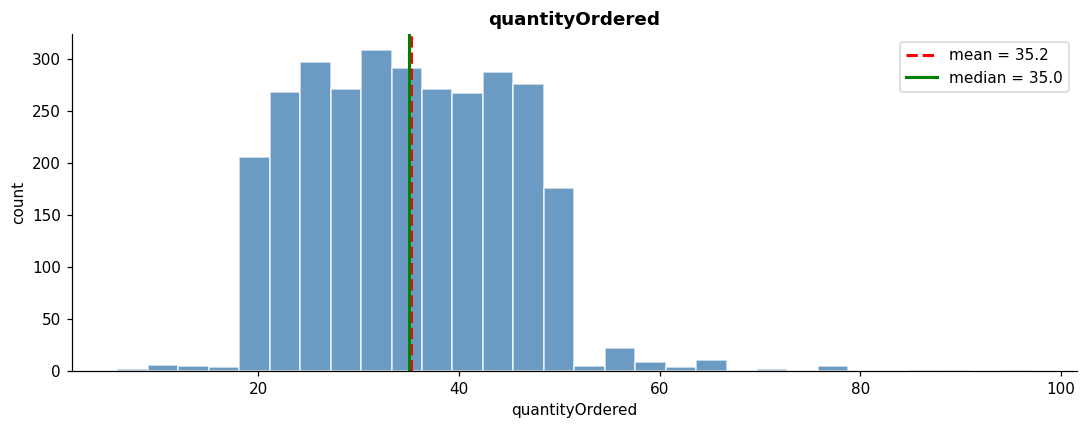

In [16]:
plot_histogram(df, "quantityOrdered")

In [18]:
df["orderNumber"].duplicated().sum()

np.int64(2670)

In [19]:
df_drop_dup_order_num = df.drop_duplicates(subset="orderNumber")

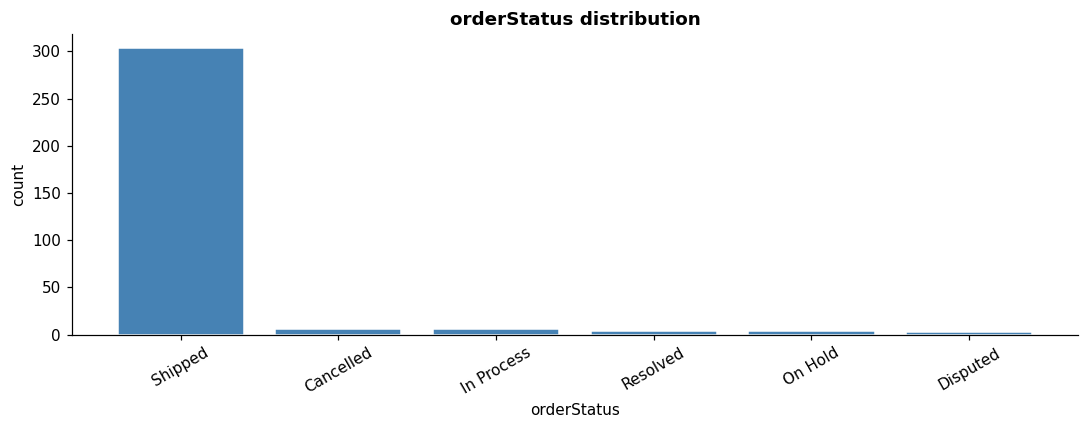

In [20]:
plot_countbar(df.drop_duplicates(subset="orderNumber"), "orderStatus")

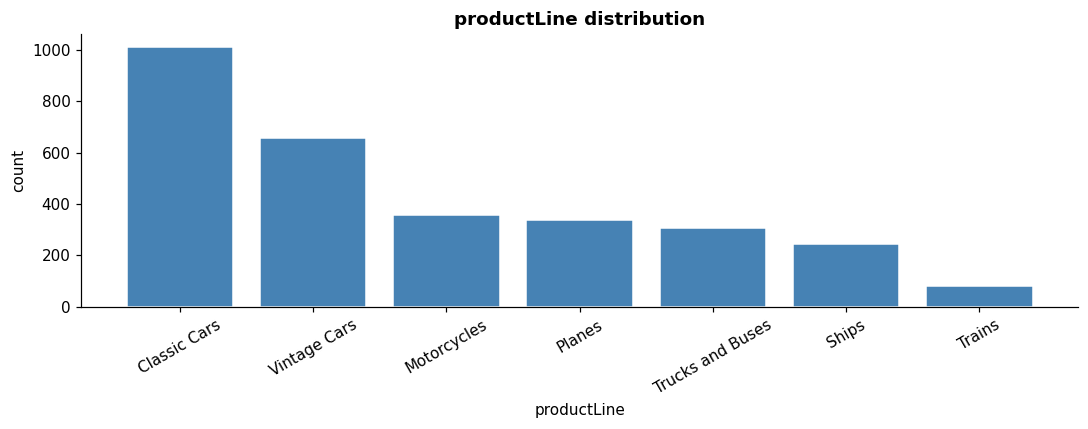

In [21]:
plot_countbar(df, "productLine")

## Phân tích nhị biến

In [22]:
import datetime as dt

In [23]:
df["year"] = df["orderDate"].dt.year
df["month"] = df["orderDate"].dt.month
df["quarter"] = df["orderDate"].dt.quarter


In [24]:
df["year_month"] = df["orderDate"].dt.strftime("%Y-%m")

In [25]:
df.head()

,orderNumber,orderDate,shippedDate,orderStatus,customerNumber,customerName,customerCountry,customerCity,creditLimit,salesRep,...,productLine,quantityInStock,quantityOrdered,priceEach,lineRevenue,isShipped,year,month,quarter,year_month
0,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,2724,30,136.000000,4080.000000,1,2003,1,1,2003-01
1,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,540,50,55.090000,2754.500000,1,2003,1,1,2003-01
2,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,6553,22,75.459999,1660.119995,1,2003,1,1,2003-01
3,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,2081,49,35.290001,1729.209961,1,2003,1,1,2003-01
4,10101,2003-01-09,2003-01-11,Shipped,128,"Blauer See Auto, Co.",Germany,Frankfurt,59700.0,Barry Jones,...,Vintage Cars,9354,25,108.059998,2701.500000,1,2003,1,1,2003-01


# Outlier

## Detech Outlier

In [28]:
# 1.5 IQR

col = "lineRevenue"
data_outlier = df[col].dropna()

In [29]:
Q1 = data_outlier.quantile(0.25)
Q3 = data_outlier.quantile(0.75)
print(f"Q1 is {Q1} and Q3 is {Q3}")

Q1 is 1990.2750244140625 and Q3 is 4093.9200439453125


In [30]:
IQR = Q3 - Q1
lower = Q1 - IQR * 1.5
upper = Q3 + IQR * 1.5

In [31]:
n_low = (data_outlier < lower).sum()
n_high = (data_outlier > upper).sum()
n_out = n_low + n_high
n_out

np.int64(76)

In [16]:
from utils.outlier import *

In [33]:
detect_outliers(df["lineRevenue"])

{'lower': np.float64(-1165.1925048828125),
 'upper': np.float64(7249.3875732421875),
 'mask': 0       False
 1       False
 2       False
 3       False
 4       False
         ...  
 2991    False
 2992    False
 2993    False
 2994    False
 2995    False
 Name: lineRevenue, Length: 2996, dtype: bool,
 'n_out': 76,
 'pct_out': np.float64(2.5)}

In [34]:
outlier_summary(df,["lineRevenue","quantityOrdered","priceEach"])

column                      lower      upper    n_out    pct
------------------------------------------------------------
lineRevenue              -1,165.2    7,249.4       76   2.5%
quantityOrdered               3.0       67.0       10   0.3%
priceEach                   -17.0      193.6       29   1.0%


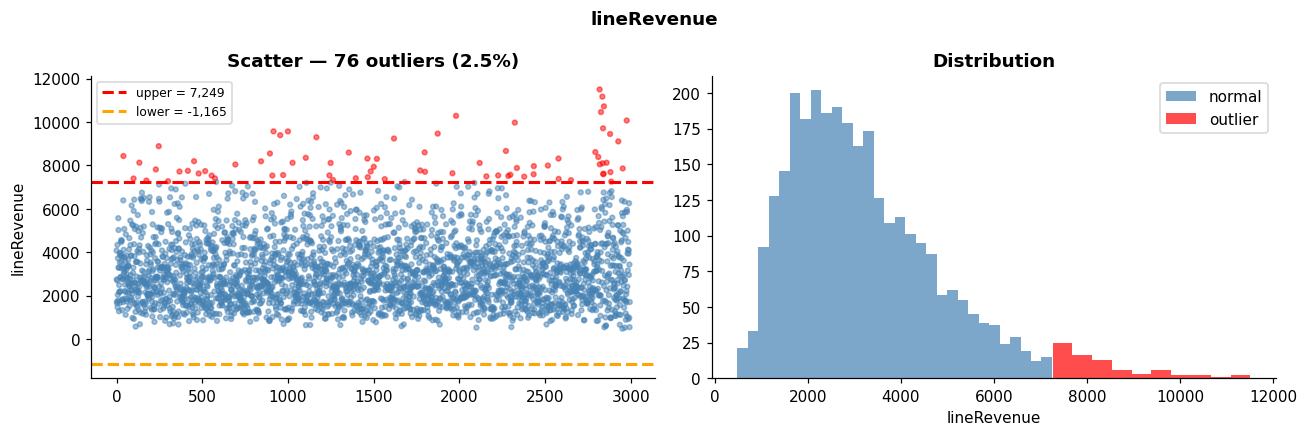

In [74]:
plot_outlier(df,"lineRevenue")

## Manage Outlier

In [38]:
# Capping

cap_outliers(df, ["lineRevenue"])

column                   before_max    after_max  n_changed
------------------------------------------------------------
lineRevenue                11,503.1      7,249.4         76

Row count unchanged: 2,996


,orderNumber,orderDate,shippedDate,orderStatus,customerNumber,customerName,customerCountry,customerCity,creditLimit,salesRep,...,productLine,quantityInStock,quantityOrdered,priceEach,lineRevenue,isShipped,year,month,quarter,year_month
0,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,2724,30,136.000000,4080.000000,1,2003,1,1,2003-01
1,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,540,50,55.090000,2754.500000,1,2003,1,1,2003-01
2,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,6553,22,75.459999,1660.119995,1,2003,1,1,2003-01
3,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,2081,49,35.290001,1729.209961,1,2003,1,1,2003-01
4,10101,2003-01-09,2003-01-11,Shipped,128,"Blauer See Auto, Co.",Germany,Frankfurt,59700.0,Barry Jones,...,Vintage Cars,9354,25,108.059998,2701.500000,1,2003,1,1,2003-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2991,10425,2005-05-31,NaT,In Process,119,La Rochelle Gifts,France,Nantes,118200.0,Gerard Hernandez,...,Trucks and Buses,2327,49,127.790001,6261.709961,0,2005,5,2,2005-05
2992,10425,2005-05-31,NaT,In Process,119,La Rochelle Gifts,France,Nantes,118200.0,Gerard Hernandez,...,Classic Cars,2542,31,31.820000,986.419983,0,2005,5,2,2005-05
2993,10425,2005-05-31,NaT,In Process,119,La Rochelle Gifts,France,Nantes,118200.0,Gerard Hernandez,...,Trucks and Buses,5099,41,83.790001,3435.389893,0,2005,5,2,2005-05
2994,10425,2005-05-31,NaT,In Process,119,La Rochelle Gifts,France,Nantes,118200.0,Gerard Hernandez,...,Trucks and Buses,2874,11,50.320000,553.520020,0,2005,5,2,2005-05


In [17]:
df_no_outlier = cap_outliers(df, ["lineRevenue"])

column                   before_max    after_max  n_changed
------------------------------------------------------------
lineRevenue                11,503.1      7,249.4         76

Row count unchanged: 2,996


In [43]:
df_no_outlier.head()

,orderNumber,orderDate,shippedDate,orderStatus,customerNumber,customerName,customerCountry,customerCity,creditLimit,salesRep,...,productLine,quantityInStock,quantityOrdered,priceEach,lineRevenue,isShipped,year,month,quarter,year_month
0,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,2724,30,136.000000,4080.000000,1,2003,1,1,2003-01
1,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,540,50,55.090000,2754.500000,1,2003,1,1,2003-01
2,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,6553,22,75.459999,1660.119995,1,2003,1,1,2003-01
3,10100,2003-01-06,2003-01-10,Shipped,363,Online Diecast Creations Co.,USA,Nashua,114200.0,Steve Patterson,...,Vintage Cars,2081,49,35.290001,1729.209961,1,2003,1,1,2003-01
4,10101,2003-01-09,2003-01-11,Shipped,128,"Blauer See Auto, Co.",Germany,Frankfurt,59700.0,Barry Jones,...,Vintage Cars,9354,25,108.059998,2701.500000,1,2003,1,1,2003-01


In [44]:
df_no_outlier.info()

<class 'pandas.DataFrame'>
RangeIndex: 2996 entries, 0 to 2995
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   orderNumber      2996 non-null   int16        
 1   orderDate        2996 non-null   datetime64[s]
 2   shippedDate      2855 non-null   datetime64[s]
 3   orderStatus      2996 non-null   str          
 4   customerNumber   2996 non-null   int16        
 5   customerName     2996 non-null   str          
 6   customerCountry  2996 non-null   str          
 7   customerCity     2996 non-null   str          
 8   creditLimit      2996 non-null   float32      
 9   salesRep         2996 non-null   str          
 10  productName      2996 non-null   str          
 11  productLine      2996 non-null   str          
 12  quantityInStock  2996 non-null   int16        
 13  quantityOrdered  2996 non-null   int8         
 14  priceEach        2996 non-null   float32      
 15  lineRevenue    

In [35]:
df_corr_check = df[['quantityInStock','quantityOrdered','priceEach','lineRevenue']]

In [48]:
df_corr_check = df_corr_check.corr()
df_corr_check

,quantityInStock,quantityOrdered,priceEach,lineRevenue
quantityInStock,1.000000,0.018409,0.056013,0.052517
quantityOrdered,0.018409,1.000000,0.024647,0.575028
priceEach,0.056013,0.024647,1.000000,0.803216
lineRevenue,0.052517,0.575028,0.803216,1.000000


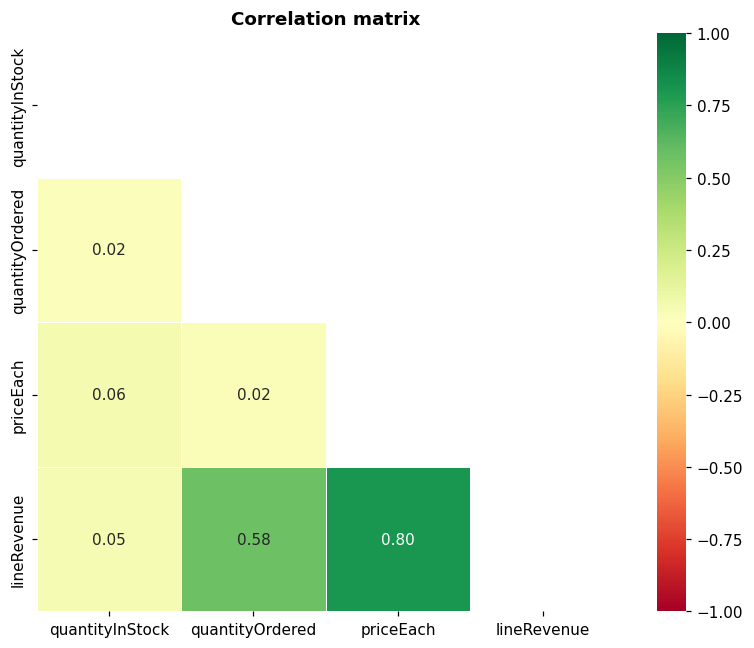

In [36]:
plot_heatmap_corr(df,['quantityInStock','quantityOrdered','priceEach','lineRevenue'])

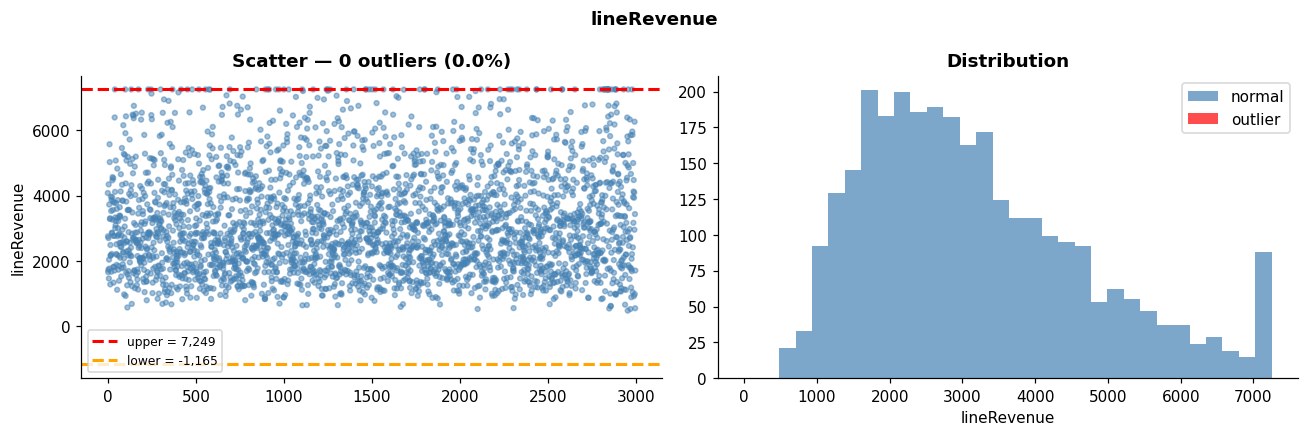

In [42]:
plot_outlier(df_no_outlier,"lineRevenue")

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
print("\n" + "🔴"*35)
print("MODEL 1: TRAINING TRÊN DỮ LIỆU CÓ OUTLIERS")
print("🔴"*35)

# Chọn features
X_with_outliers = df[['quantityInStock','quantityOrdered','priceEach']]
y_with_outliers = df['lineRevenue']

# Chia train/test (80/20)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_with_outliers, y_with_outliers, test_size=0.2, random_state=42
)

print(f"""
✅ Chia dữ liệu:
   • Train: {len(X_train_1)} mẫu
   • Test:  {len(X_test_1)} mẫu
   • Tổng:  {len(X_with_outliers)} mẫu
""")

# Train model
model_1 = LinearRegression()
model_1.fit(X_train_1, y_train_1)

print(f"✅ Model 1 đã huấn luyện!")

# Dự báo
y_pred_1 = model_1.predict(X_test_1)

# Tính metrics
mae_1 = mean_absolute_error(y_test_1, y_pred_1)
rmse_1 = np.sqrt(mean_squared_error(y_test_1, y_pred_1))
r2_1 = r2_score(y_test_1, y_pred_1)

print(f"""
📊 KẾT QUẢ ĐÁNH GIÁ MODEL 1:
   • MAE:  ${mae_1:.2f}
   • RMSE: ${rmse_1:.2f}
   • R²:   {r2_1:.4f}
""")


🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
MODEL 1: TRAINING TRÊN DỮ LIỆU CÓ OUTLIERS
🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴

✅ Chia dữ liệu:
   • Train: 2396 mẫu
   • Test:  600 mẫu
   • Tổng:  2996 mẫu

✅ Model 1 đã huấn luyện!

📊 KẾT QUẢ ĐÁNH GIÁ MODEL 1:
   • MAE:  $246.36
   • RMSE: $363.97
   • R²:   0.9523



In [38]:
print("\n" + "🟢"*35)
print("MODEL 2: TRAINING TRÊN DỮ LIỆU KHÔNG OUTLIERS")
print("🟢"*35)

# Chọn features
X_clean = df_no_outlier[['quantityInStock','quantityOrdered','priceEach']]
y_clean = df_no_outlier['lineRevenue']

# Chia train/test (80/20)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

print(f"""
✅ Chia dữ liệu:
   • Train: {len(X_train_2)} mẫu
   • Test:  {len(X_test_2)} mẫu
   • Tổng:  {len(X_clean)} mẫu
""")

# Train model
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)

print(f"✅ Model 2 đã huấn luyện!")

# Dự báo
y_pred_2 = model_2.predict(X_test_2)

# Tính metrics
mae_2 = mean_absolute_error(y_test_2, y_pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_test_2, y_pred_2))
r2_2 = r2_score(y_test_2, y_pred_2)

print(f"""
📊 KẾT QUẢ ĐÁNH GIÁ MODEL 2:
   • MAE:  ${mae_2:.2f}
   • RMSE: ${rmse_2:.2f}
   • R²:   {r2_2:.4f}
""")


🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢
MODEL 2: TRAINING TRÊN DỮ LIỆU KHÔNG OUTLIERS
🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢

✅ Chia dữ liệu:
   • Train: 2396 mẫu
   • Test:  600 mẫu
   • Tổng:  2996 mẫu

✅ Model 2 đã huấn luyện!

📊 KẾT QUẢ ĐÁNH GIÁ MODEL 2:
   • MAE:  $225.66
   • RMSE: $318.35
   • R²:   0.9586




SO SÁNH 2 MODEL: OUTLIERS VS KHÔNG OUTLIERS

  Metric Model 1 (Có Outliers) Model 2 (Không Outliers)
     MAE               $246.36                  $225.66
    RMSE               $363.97                  $318.35
R² Score                0.9523                   0.9586

📈 SỰ THAY ĐỔI KHI LOẠI BỎ OUTLIERS:

   🔴 MAE:  $246.36 → $225.66
      ➜ Cải thiện: 8.4%
      ➜ Giải thích: Sai số trung bình GIẢM 8.4%

   🔴 RMSE: $363.97 → $318.35
      ➜ Cải thiện: 12.5%
      ➜ Giải thích: Sai số bình phương GIẢM 12.5%

   🟢 R²:   0.9523 → 0.9586
      ➜ Cải thiện: +0.7%
      ➜ Giải thích: Mô hình giải thích TĂNG 0.7% sự biến động



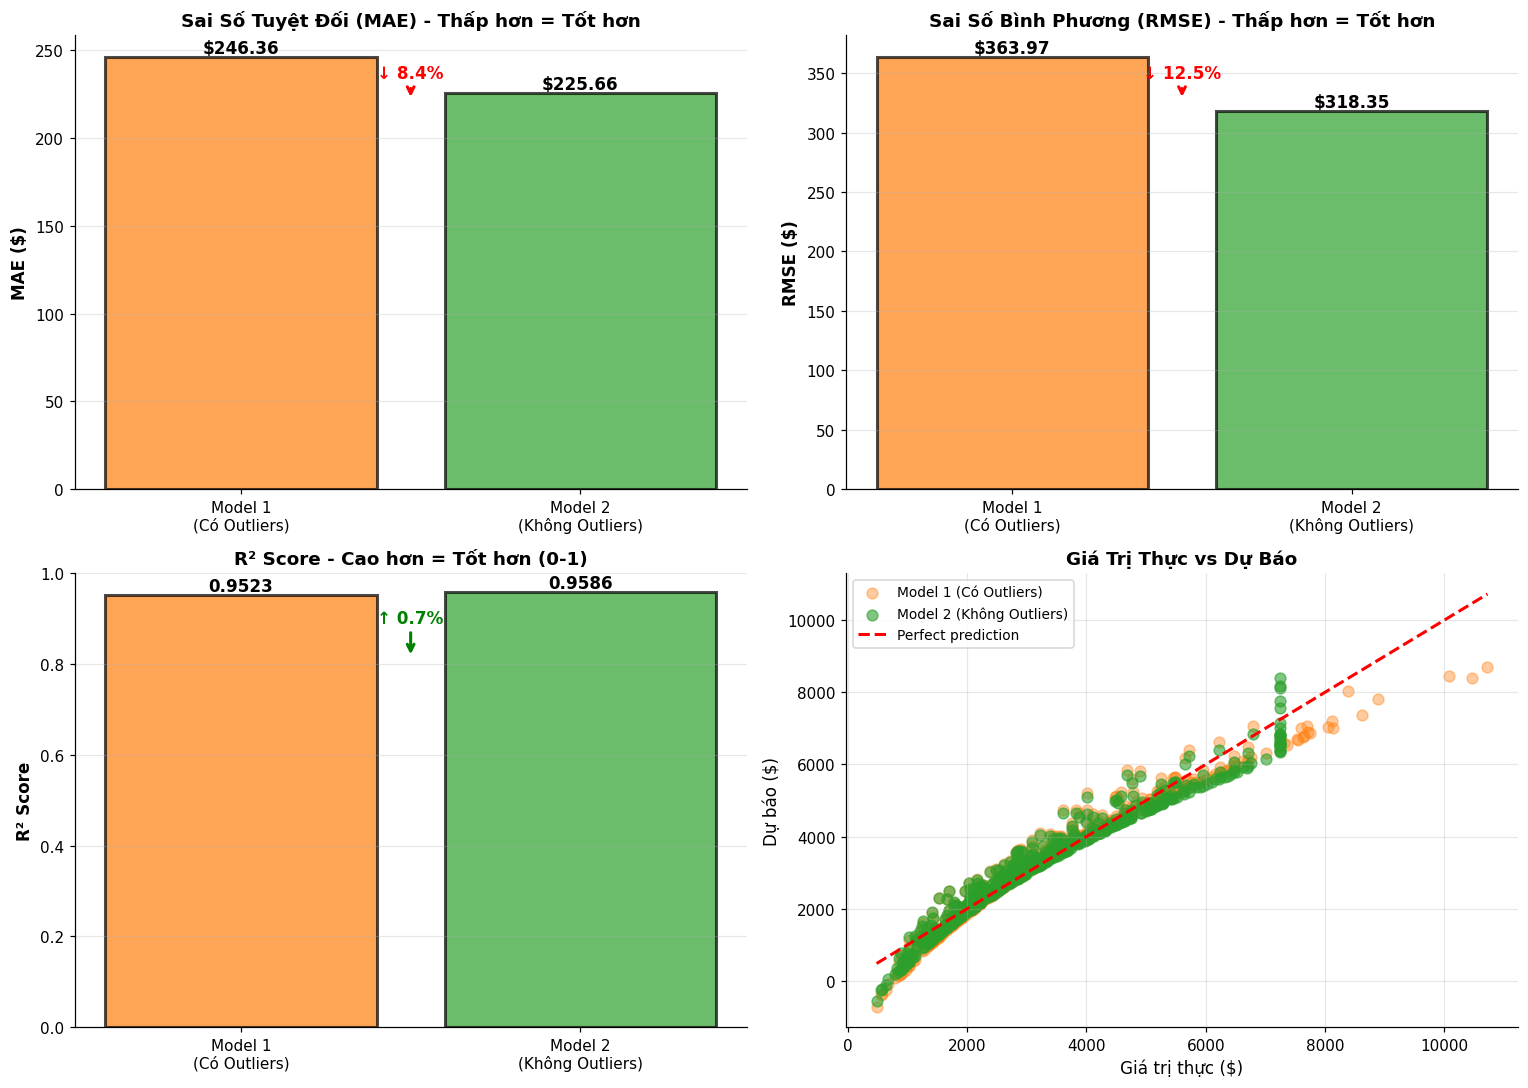


💡 KẾT LUẬN

✅ LOẠI BỎ OUTLIERS CÓ LỢI:

1️⃣ SAI SỐ GIẢM:
   • Sai số trung bình giảm 8.4%
   • Sai số bình phương giảm 12.5%
   ➜ Model dự báo CHÍNH XÁC hơn

2️⃣ MỘ HÌNH GIẢI THÍCH TỐT HƠN:
   • R² tăng từ 0.9523 lên 0.9586
   • Giải thích thêm 0.7% sự biến động dữ liệu
   ➜ Mô hình PHÙ HỢP với dữ liệu bình thường hơn

3️⃣ LÝ DO:
   • Outliers "kéo" mô hình khỏi xu hướng chính
   • Mô hình cố gắng fit những điểm bất thường
   • Loại outliers → Mô hình tập trung vào "bình thường"

4️⃣ KHU NIÊN:
   • Dùng Model 2 (không outliers) để dự báo
   • Model này tin cậy hơn cho các đơn hàng "bình thường"
   • Chỉ cảnh báo nếu dự báo một đơn hàng "bất thường"



In [39]:
print("\n" + "="*70)
print("SO SÁNH 2 MODEL: OUTLIERS VS KHÔNG OUTLIERS")
print("="*70)

# Tạo bảng so sánh
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Model 1 (Có Outliers)': [f'${mae_1:.2f}', f'${rmse_1:.2f}', f'{r2_1:.4f}'],
    'Model 2 (Không Outliers)': [f'${mae_2:.2f}', f'${rmse_2:.2f}', f'{r2_2:.4f}']
})

print("\n" + comparison_df.to_string(index=False))

# Tính sự thay đổi
mae_improvement = ((mae_1 - mae_2) / mae_1 * 100) if mae_1 != 0 else 0
rmse_improvement = ((rmse_1 - rmse_2) / rmse_1 * 100) if rmse_1 != 0 else 0
r2_improvement = ((r2_2 - r2_1) / r2_1 * 100) if r2_1 != 0 else 0

print(f"""
📈 SỰ THAY ĐỔI KHI LOẠI BỎ OUTLIERS:

   🔴 MAE:  ${mae_1:.2f} → ${mae_2:.2f}
      ➜ Cải thiện: {mae_improvement:.1f}%
      ➜ Giải thích: Sai số trung bình GIẢM {abs(mae_improvement):.1f}%

   🔴 RMSE: ${rmse_1:.2f} → ${rmse_2:.2f}
      ➜ Cải thiện: {rmse_improvement:.1f}%
      ➜ Giải thích: Sai số bình phương GIẢM {abs(rmse_improvement):.1f}%

   🟢 R²:   {r2_1:.4f} → {r2_2:.4f}
      ➜ Cải thiện: {r2_improvement:+.1f}%
      ➜ Giải thích: Mô hình giải thích TĂNG {abs(r2_improvement):.1f}% sự biến động
""")

# Visualize so sánh
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAE so sánh
ax = axes[0, 0]
categories = ['Model 1\n(Có Outliers)', 'Model 2\n(Không Outliers)']
mae_values = [mae_1, mae_2]
colors = ['#ff7f0e', '#2ca02c']
bars = ax.bar(categories, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('MAE ($)', fontsize=11, fontweight='bold')
ax.set_title('Sai Số Tuyệt Đối (MAE) - Thấp hơn = Tốt hơn', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, mae_values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'${val:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.annotate(f'↓ {mae_improvement:.1f}%', xy=(0.5, max(mae_values)*0.9), 
            xytext=(0.5, max(mae_values)*0.95), ha='center', fontsize=11, 
            color='red', fontweight='bold', arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Plot 2: RMSE so sánh
ax = axes[0, 1]
rmse_values = [rmse_1, rmse_2]
bars = ax.bar(categories, rmse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('RMSE ($)', fontsize=11, fontweight='bold')
ax.set_title('Sai Số Bình Phương (RMSE) - Thấp hơn = Tốt hơn', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rmse_values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'${val:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.annotate(f'↓ {rmse_improvement:.1f}%', xy=(0.5, max(rmse_values)*0.9), 
            xytext=(0.5, max(rmse_values)*0.95), ha='center', fontsize=11, 
            color='red', fontweight='bold', arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Plot 3: R² so sánh
ax = axes[1, 0]
r2_values = [r2_1, r2_2]
bars = ax.bar(categories, r2_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax.set_title('R² Score - Cao hơn = Tốt hơn (0-1)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.annotate(f'↑ {r2_improvement:.1f}%', xy=(0.5, max(r2_values)*0.85), 
            xytext=(0.5, max(r2_values)*0.93), ha='center', fontsize=11, 
            color='green', fontweight='bold', arrowprops=dict(arrowstyle='->', color='green', lw=2))

# Plot 4: Giá trị thực vs Dự báo (so sánh visual)
ax = axes[1, 1]
ax.scatter(y_test_1, y_pred_1, alpha=0.4, s=50, color='#ff7f0e', label='Model 1 (Có Outliers)')
ax.scatter(y_test_2, y_pred_2, alpha=0.6, s=50, color='#2ca02c', label='Model 2 (Không Outliers)')
ax.plot([y_test_1.min(), y_test_1.max()], [y_test_1.min(), y_test_1.max()], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Giá trị thực ($)', fontsize=11)
ax.set_ylabel('Dự báo ($)', fontsize=11)
ax.set_title('Giá Trị Thực vs Dự Báo', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 KẾT LUẬN")
print("="*70)
print(f"""
✅ LOẠI BỎ OUTLIERS CÓ LỢI:

1️⃣ SAI SỐ GIẢM:
   • Sai số trung bình giảm {abs(mae_improvement):.1f}%
   • Sai số bình phương giảm {abs(rmse_improvement):.1f}%
   ➜ Model dự báo CHÍNH XÁC hơn

2️⃣ MỘ HÌNH GIẢI THÍCH TỐT HƠN:
   • R² tăng từ {r2_1:.4f} lên {r2_2:.4f}
   • Giải thích thêm {abs(r2_improvement):.1f}% sự biến động dữ liệu
   ➜ Mô hình PHÙ HỢP với dữ liệu bình thường hơn

3️⃣ LÝ DO:
   • Outliers "kéo" mô hình khỏi xu hướng chính
   • Mô hình cố gắng fit những điểm bất thường
   • Loại outliers → Mô hình tập trung vào "bình thường"

4️⃣ KHU NIÊN:
   • Dùng Model 2 (không outliers) để dự báo
   • Model này tin cậy hơn cho các đơn hàng "bình thường"
   • Chỉ cảnh báo nếu dự báo một đơn hàng "bất thường"
""")

In [40]:
print("\n" + "="*70)
print("WHAT-IF ANALYSIS - PHÂN TÍCH 'NẾU NHƯ'")
print("="*70)

print("""
💡 WHAT-IF là gì?
   → "Nếu tôi thay đổi cái này, kết quả sẽ thế nào?"
   → Hỗ trợ ra quyết định kinh doanh
   
Ví dụ:
   ✓ "Nếu tăng số lượng bán 20%, doanh thu tăng bao nhiêu?"
   ✓ "Nếu giảm giá 10%, ảnh hưởng đến doanh thu như thế nào?"

⭐ Dùng Model 2 (không outliers) vì nó chính xác {r2_2:.4f} (R² = {r2_2:.4f})
""")

# Lấy sample dữ liệu
baseline = X_test_2.iloc[0:1].copy()
baseline_pred = model_2.predict(baseline)[0]

# print(f"\n{'─'*70}")
# print(f"📍 BASELINE (Hiện tại)")
# print(f"{'─'*70}")
# print(f"\nThông tin đơn hàng:")
# print(f"   • Số lượng: {baseline['quantityInStock'].values[0]:.0f} sản phẩm")
# print(f"   • Giá trung bình: ${baseline['priceEach'].values[0]:.2f}")
# print(f"   • Số loại sản phẩm: {baseline['lineRevenue'].values[0]:.0f}")
# print(f"\n✅ Doanh thu dự báo (hiện tại): ${baseline_pred:.2f}")


WHAT-IF ANALYSIS - PHÂN TÍCH 'NẾU NHƯ'

💡 WHAT-IF là gì?
   → "Nếu tôi thay đổi cái này, kết quả sẽ thế nào?"
   → Hỗ trợ ra quyết định kinh doanh

Ví dụ:
   ✓ "Nếu tăng số lượng bán 20%, doanh thu tăng bao nhiêu?"
   ✓ "Nếu giảm giá 10%, ảnh hưởng đến doanh thu như thế nào?"

⭐ Dùng Model 2 (không outliers) vì nó chính xác {r2_2:.4f} (R² = {r2_2:.4f})



In [41]:
X_test_2

,quantityInStock,quantityOrdered,priceEach
1375,2378,46,88.93
932,3501,24,78.75
144,1016,27,100.70
2555,3252,39,118.32
51,1956,39,92.16
...,...,...,...
637,7995,34,53.27
695,5545,36,140.75
226,2081,46,36.11
2551,8290,41,78.99


In [42]:
baseline

,quantityInStock,quantityOrdered,priceEach
1375,2378,46,88.93


In [43]:
# ========== SCENARIO 1: Tăng số lượng bán 20% ==========
print(f"\n{'─'*70}")
print(f"SCENARIO 1: TĂNG SỐ LƯỢNG BÁN 20%")
print(f"{'─'*70}")

scenario1 = baseline.copy()
old_qty = scenario1['quantityInStock'].values[0]
new_qty = old_qty * 1.20
scenario1['quantityInStock'] = new_qty

pred1 = model_2.predict(scenario1)[0]
impact1 = pred1 - baseline_pred
impact1_pct = impact1 / baseline_pred * 100

# print(f"""
# ✏️ Điều chỉnh:
#    • Số lượng hiện tại: {old_qty:.0f} sản phẩm
#    • Số lượng mới:      {new_qty:.0f} sản phẩm (+20%)

# 📊 Kết quả:
#    • Doanh thu hiện tại: ${baseline_pred:.2f}
#    • Doanh thu dự báo:   ${pred1:.2f}
#    • 📈 Tăng:            ${impact1:+.2f} ({impact1_pct:+.2f}%)

# 💡 Kết luận:
#    Tăng số lượng bán 20% → Doanh thu tăng {impact1_pct:.1f}%
#    ✅ KHUYẾN NGHỊ: Này - đây là chiến lược tốt để tăng doanh thu!
# """)


──────────────────────────────────────────────────────────────────────
SCENARIO 1: TĂNG SỐ LƯỢNG BÁN 20%
──────────────────────────────────────────────────────────────────────


In [44]:
scenario1

,quantityInStock,quantityOrdered,priceEach
1375,2853.6,46,88.93


In [45]:
print(old_qty)
print(new_qty)
print(baseline_pred)
print(pred1)
print(impact1)
print(impact1_pct)

2378
2853.6
4048.1415615347637
4048.5531548503864
0.41159331562266743
0.010167463498154469


In [46]:
# ========== SCENARIO 3: Chiến lược kết hợp ==========
print(f"\n{'─'*70}")
print(f"SCENARIO 3: CHIẾN LƯỢC KỊ HỢP")
print(f"            (Tăng QUANTITY 25% + Giảm PRICE 8%)")
print(f"{'─'*70}")

scenario3 = baseline.copy()
old_qty_s3 = scenario3['quantityOrdered'].values[0]
old_price_s3 = scenario3['priceEach'].values[0]

new_qty_s3 = old_qty_s3 * 1.25
new_price_s3 = old_price_s3 * 0.92

scenario3['quantityOrdered'] = new_qty_s3
scenario3['priceEach'] = new_price_s3

pred3 = model_2.predict(scenario3)[0]
impact3 = pred3 - baseline_pred
impact3_pct = impact3 / baseline_pred * 100

print(f"""
✏️ Điều chỉnh:
   • Quantity: {old_qty_s3:.0f} → {new_qty_s3:.0f} (+25%)
   • Price:    ${old_price_s3:.2f} → ${new_price_s3:.2f} (-8%)

📊 Kết quả:
   • Revenue hiện tại: ${baseline_pred:.2f}
   • Revenue dự báo:   ${pred3:.2f}
   • 📈 Tăng:          ${impact3:+.2f} ({impact3_pct:+.2f}%)

💡 Kết luận:
   Chiến lược này → Revenue tăng {impact3_pct:.1f}%
   ✅ ĐÂY LÀ CHIẾN LƯỢC THÔNG MINH:
      • Giảm giá để thu hút khách hàng (tăng thị phần)
      • Tăng số lượng bán để bù lại lợi nhuận
      • Kết quả tổng thể: Tăng revenue mà không mất lợi nhuận quá nhiều
""")


──────────────────────────────────────────────────────────────────────
SCENARIO 3: CHIẾN LƯỢC KỊ HỢP
            (Tăng QUANTITY 25% + Giảm PRICE 8%)
──────────────────────────────────────────────────────────────────────

✏️ Điều chỉnh:
   • Quantity: 46 → 58 (+25%)
   • Price:    $88.93 → $81.82 (-8%)

📊 Kết quả:
   • Revenue hiện tại: $4048.14
   • Revenue dự báo:   $4805.06
   • 📈 Tăng:          $+756.92 (+18.70%)

💡 Kết luận:
   Chiến lược này → Revenue tăng 18.7%
   ✅ ĐÂY LÀ CHIẾN LƯỢC THÔNG MINH:
      • Giảm giá để thu hút khách hàng (tăng thị phần)
      • Tăng số lượng bán để bù lại lợi nhuận
      • Kết quả tổng thể: Tăng revenue mà không mất lợi nhuận quá nhiều

